# Turtle Trader Strategy — Crypto Replication

Replication of the original Richard Dennis / William Eckhardt Turtle Trading rules
on crypto spot data from DuckDB.

**Original rules (1983):**
- **System 1 (short-term):** Enter long on a 20-day high breakout, exit on a 10-day low breakout
- **System 2 (long-term):** Enter long on a 55-day high breakout, exit on a 20-day low breakout
- **Position sizing:** Risk 1% of equity per unit, where 1 unit = account_risk / (ATR × dollar_per_point)
- **Pyramiding:** Add up to 4 units per market, each 0.5 ATR apart
- **Stops:** 2× ATR from entry price (hard stop)

**Adaptation for crypto:**
- Long-only / cash (no shorting) — consistent with our convexity mandate
- We test both systems plus a combined version
- ATR-based position sizing with configurable risk-per-trade
- We also test a simple binary (equal-weight) variant for comparison
- Applied to top liquid assets individually and as a portfolio

In [1]:
from _setup import *

[setup] Project: trend_crypto  |  DuckDB: /Users/russellfloyd/Dropbox/NRT/nrt_dev/data/market.duckdb
[setup] Ready — np, pd, plt, load_daily_bars, simple_backtest, compute_metrics, ...


## 1. Configuration

In [2]:
# Assets to test
SYMBOLS = ["BTC-USD", "ETH-USD", "SOL-USD"]

# Date range
START = "2017-01-01"
END   = "2026-12-31"

# Turtle parameters
SYS1_ENTRY   = 20   # System 1: N-day high breakout for entry
SYS1_EXIT    = 10   # System 1: N-day low breakout for exit
SYS2_ENTRY   = 55   # System 2: N-day high breakout for entry
SYS2_EXIT    = 20   # System 2: N-day low breakout for exit
ATR_PERIOD   = 20   # ATR lookback (Turtles used 20-day "N")
RISK_PER_TRADE = 0.01  # 1% of equity risked per unit
ATR_STOP_MULT  = 2.0   # Hard stop at 2x ATR from entry
MAX_UNITS      = 4     # Maximum pyramid units per position
PYRAMID_ATR    = 0.5   # Add next unit every 0.5 ATR in profit

# Transaction costs
COST_BPS = 20.0

## 2. Load data

In [3]:
panel = load_daily_bars(start=START, end=END)

# Build per-asset OHLCV frames
assets = {}
for sym in SYMBOLS:
    df = panel[panel["symbol"] == sym].copy().sort_values("ts").set_index("ts")
    if len(df) < 100:
        print(f"  {sym}: only {len(df)} bars, skipping")
        continue
    assets[sym] = df
    print(f"  {sym}: {len(df)} bars, {df.index.min().date()} to {df.index.max().date()}")

print(f"\nLoaded {len(assets)} assets")

[data] Loading cached daily bars from /Users/russellfloyd/Dropbox/NRT/nrt_dev/trend_crypto/scripts/research/common/_cache/bars_1d_2017-01-01_2026-12-31.parquet
  BTC-USD: 3330 bars, 2017-01-02 to 2026-02-13
  ETH-USD: 3330 bars, 2017-01-02 to 2026-02-13
  SOL-USD: 1703 bars, 2021-06-17 to 2026-02-13

Loaded 3 assets


## 3. Core Turtle functions

In [5]:
def compute_atr(high: pd.Series, low: pd.Series, close: pd.Series, period: int = 20) -> pd.Series:
    """True Range averaged over `period` days (the Turtle 'N')."""
    prev_close = close.shift(1)
    tr = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low - prev_close).abs(),
    ], axis=1).max(axis=1)
    return tr.rolling(period, min_periods=period).mean()


def turtle_signals(
    close: pd.Series, high: pd.Series, low: pd.Series,
    entry_period: int, exit_period: int,
) -> pd.Series:
    """
    Binary Turtle breakout signal.
    Long when close > highest high of prior `entry_period` days.
    Flat when close < lowest low of prior `exit_period` days.
    In between: hold previous state.
    """
    entry_high = high.shift(1).rolling(entry_period, min_periods=entry_period).max()
    exit_low   = low.shift(1).rolling(exit_period, min_periods=exit_period).min()

    signal = pd.Series(np.nan, index=close.index)
    signal[close > entry_high] = 1.0
    signal[close < exit_low]   = 0.0
    signal = signal.ffill().fillna(0.0)
    return signal


def turtle_sized_signal(
    close: pd.Series, high: pd.Series, low: pd.Series,
    atr: pd.Series,
    entry_period: int, exit_period: int,
    risk_per_trade: float = 0.01,
    atr_stop_mult: float = 2.0,
    max_units: int = 4,
    pyramid_atr: float = 0.5,
) -> pd.Series:
    """
    Full Turtle position sizing: ATR-based units with pyramiding and hard stops.
    Returns fractional weight (sum of unit sizes, capped at max_units * unit_size).
    """
    n = len(close)
    pos = np.zeros(n)
    entry_high = high.shift(1).rolling(entry_period, min_periods=entry_period).max().values
    exit_low   = low.shift(1).rolling(exit_period, min_periods=exit_period).min().values
    atr_vals   = atr.values
    close_vals = close.values

    in_trade = False
    units = 0
    entry_price = 0.0
    last_add_price = 0.0
    stop_price = 0.0
    current_atr = 0.0

    for i in range(1, n):
        c = close_vals[i]
        a = atr_vals[i]

        if np.isnan(a) or np.isnan(entry_high[i]) or np.isnan(exit_low[i]):
            pos[i] = 0.0
            continue

        if in_trade:
            # Check hard stop
            if c <= stop_price:
                in_trade = False
                units = 0
                pos[i] = 0.0
                continue

            # Check channel exit
            if c < exit_low[i]:
                in_trade = False
                units = 0
                pos[i] = 0.0
                continue

            # Pyramiding: add unit every pyramid_atr * ATR above last add
            if units < max_units and c >= last_add_price + pyramid_atr * current_atr:
                units += 1
                last_add_price = c
                # Tighten stop: 2*ATR below most recent entry
                stop_price = c - atr_stop_mult * a

            # Unit size: risk_per_trade / (atr_stop_mult * ATR / price)
            unit_weight = risk_per_trade / (atr_stop_mult * a / c) if a > 0 else 0.0
            pos[i] = min(units * unit_weight, 1.0)  # cap total weight at 100%

        else:
            # Check for breakout entry
            if c > entry_high[i]:
                in_trade = True
                units = 1
                entry_price = c
                last_add_price = c
                current_atr = a
                stop_price = c - atr_stop_mult * a

                unit_weight = risk_per_trade / (atr_stop_mult * a / c) if a > 0 else 0.0
                pos[i] = min(unit_weight, 1.0)
            else:
                pos[i] = 0.0

    return pd.Series(pos, index=close.index)

## 4. Generate signals for each asset

In [6]:
all_signals = {}

for sym, df in assets.items():
    close, high, low = df["close"], df["high"], df["low"]
    atr = compute_atr(high, low, close, ATR_PERIOD)

    # Binary signals (simple long/cash)
    s1_bin = turtle_signals(close, high, low, SYS1_ENTRY, SYS1_EXIT)
    s2_bin = turtle_signals(close, high, low, SYS2_ENTRY, SYS2_EXIT)
    combined_bin = ((s1_bin + s2_bin) > 0).astype(float)  # long if either fires

    # ATR-sized signals (full Turtle sizing with pyramiding)
    s1_sized = turtle_sized_signal(
        close, high, low, atr, SYS1_ENTRY, SYS1_EXIT,
        RISK_PER_TRADE, ATR_STOP_MULT, MAX_UNITS, PYRAMID_ATR,
    )
    s2_sized = turtle_sized_signal(
        close, high, low, atr, SYS2_ENTRY, SYS2_EXIT,
        RISK_PER_TRADE, ATR_STOP_MULT, MAX_UNITS, PYRAMID_ATR,
    )
    combined_sized = (s1_sized + s2_sized).clip(upper=1.0)

    all_signals[sym] = {
        "Sys1 Binary": s1_bin,
        "Sys2 Binary": s2_bin,
        "Combined Binary": combined_bin,
        "Sys1 ATR-Sized": s1_sized,
        "Sys2 ATR-Sized": s2_sized,
        "Combined ATR-Sized": combined_sized,
    }

    # Quick diagnostics
    print(f"\n{sym}:")
    for name, sig in all_signals[sym].items():
        tim = sig.mean()
        n_trades = (sig.diff().abs() > 0.01).sum()
        print(f"  {name:22s}  TIM={tim:.1%}  trades={n_trades}  avg_weight={sig[sig>0].mean():.2f}")


BTC-USD:
  Sys1 Binary             TIM=47.1%  trades=86  avg_weight=1.00
  Sys2 Binary             TIM=42.5%  trades=44  avg_weight=1.00
  Combined Binary         TIM=56.1%  trades=74  avg_weight=1.00
  Sys1 ATR-Sized          TIM=16.0%  trades=719  avg_weight=0.37
  Sys2 ATR-Sized          TIM=13.4%  trades=633  avg_weight=0.37
  Combined ATR-Sized      TIM=27.8%  trades=861  avg_weight=0.56

ETH-USD:
  Sys1 Binary             TIM=43.0%  trades=90  avg_weight=1.00
  Sys2 Binary             TIM=38.0%  trades=42  avg_weight=1.00
  Combined Binary         TIM=49.1%  trades=76  avg_weight=1.00
  Sys1 ATR-Sized          TIM=10.5%  trades=642  avg_weight=0.27
  Sys2 ATR-Sized          TIM=9.4%  trades=531  avg_weight=0.29
  Combined ATR-Sized      TIM=19.6%  trades=862  avg_weight=0.45

SOL-USD:
  Sys1 Binary             TIM=36.1%  trades=48  avg_weight=1.00
  Sys2 Binary             TIM=31.2%  trades=22  avg_weight=1.00
  Combined Binary         TIM=43.3%  trades=44  avg_weight=1.00
  Sys

## 5. Per-asset backtest

In [7]:
per_asset_results = {}

for sym, df in assets.items():
    returns = df["close"].pct_change(fill_method=None).dropna()
    ret_df = returns.to_frame(name=sym)

    results = []

    # Buy & Hold benchmark
    bh_w = pd.DataFrame(1.0, index=ret_df.index, columns=[sym])
    results.append(quick_backtest(bh_w, ret_df, COST_BPS, "Buy & Hold"))

    # Each Turtle variant
    for name, sig in all_signals[sym].items():
        w = sig.to_frame(name=sym)
        results.append(quick_backtest(w, ret_df, COST_BPS, name))

    per_asset_results[sym] = results

    print(f"\n{'='*60}")
    print(f"  {sym}")
    print(f"{'='*60}")
    display(metrics_table(results))


  BTC-USD


,total_return,cagr,vol,sharpe,sortino,calmar,max_dd,hit_rate,skewness,kurtosis,n_days,avg_turnover,avg_gross
strategy,,,,,,,,,,,,,
Buy & Hold,66.296702,58.6%,70.0%,1.01,1.39,0.70,-83.8%,51.9%,-0.01,7.910782,3329,0.00,100.0%
Sys1 Binary,81.044411,62.1%,47.1%,1.26,1.31,1.17,-53.1%,25.1%,0.88,11.947306,3329,0.03,47.1%
Sys2 Binary,26.354648,43.7%,45.0%,1.03,1.00,0.82,-53.2%,22.4%,0.76,12.759516,3329,0.01,42.5%
Combined Binary,78.599175,61.6%,50.1%,1.21,1.36,1.07,-57.5%,29.5%,0.71,9.517796,3329,0.02,56.1%
Sys1 ATR-Sized,4.857304,21.4%,17.0%,1.23,1.23,1.06,-20.2%,22.9%,1.59,20.513448,3329,0.02,16.0%
Sys2 ATR-Sized,2.144665,13.4%,15.0%,0.91,0.84,0.60,-22.1%,19.0%,1.15,17.289664,3329,0.01,13.4%
Combined ATR-Sized,14.582969,35.1%,28.7%,1.19,1.24,0.97,-36.3%,26.1%,1.25,17.034062,3329,0.02,27.8%



  ETH-USD


,total_return,cagr,vol,sharpe,sortino,calmar,max_dd,hit_rate,skewness,kurtosis,n_days,avg_turnover,avg_gross
strategy,,,,,,,,,,,,,
Buy & Hold,212.134961,80.0%,93.9%,1.09,1.61,0.85,-94.0%,51.4%,0.36,6.483582,3329,0.00,100.0%
Sys1 Binary,332.726689,89.1%,66.5%,1.28,1.40,1.26,-70.8%,22.2%,1.50,15.362900,3329,0.03,43.0%
Sys2 Binary,203.224090,79.2%,62.4%,1.24,1.21,1.14,-69.7%,20.3%,1.55,20.295321,3329,0.01,38.1%
Combined Binary,314.792604,87.9%,69.2%,1.25,1.38,1.31,-67.0%,25.3%,1.17,14.160274,3329,0.02,49.1%
Sys1 ATR-Sized,5.002983,21.7%,16.9%,1.25,1.24,1.12,-19.4%,20.3%,1.56,19.290217,3329,0.01,10.5%
Sys2 ATR-Sized,5.619003,23.0%,16.3%,1.35,1.27,1.31,-17.6%,17.7%,1.95,20.945374,3329,0.01,9.4%
Combined ATR-Sized,29.779876,45.6%,31.7%,1.34,1.39,1.42,-32.2%,22.4%,1.96,21.176120,3329,0.02,19.6%



  SOL-USD


,total_return,cagr,vol,sharpe,sortino,calmar,max_dd,hit_rate,skewness,kurtosis,n_days,avg_turnover,avg_gross
strategy,,,,,,,,,,,,,
Buy & Hold,1.282547,19.4%,101.4%,0.68,1.07,0.20,-96.3%,49.4%,0.17,5.147227,1702,0.00,99.9%
Sys1 Binary,7.519241,58.3%,61.7%,1.04,1.23,0.85,-68.7%,17.6%,1.97,15.207940,1702,0.03,36.1%
Sys2 Binary,5.193296,47.9%,60.2%,0.94,1.07,0.70,-68.0%,15.5%,2.17,16.997142,1702,0.01,31.2%
Combined Binary,5.623838,50.0%,66.5%,0.93,1.20,0.69,-73.0%,21.0%,1.71,11.743640,1702,0.03,43.3%
Sys1 ATR-Sized,0.782591,13.2%,13.7%,0.97,1.01,0.83,-16.0%,15.8%,2.09,17.276513,1702,0.01,7.2%
Sys2 ATR-Sized,0.738681,12.6%,12.2%,1.03,0.94,0.74,-17.1%,12.5%,1.93,17.361887,1702,0.01,5.3%
Combined ATR-Sized,1.911298,25.8%,24.8%,1.05,1.10,0.82,-31.3%,17.7%,2.10,17.634706,1702,0.02,12.5%


## 6. Equity curves — per asset

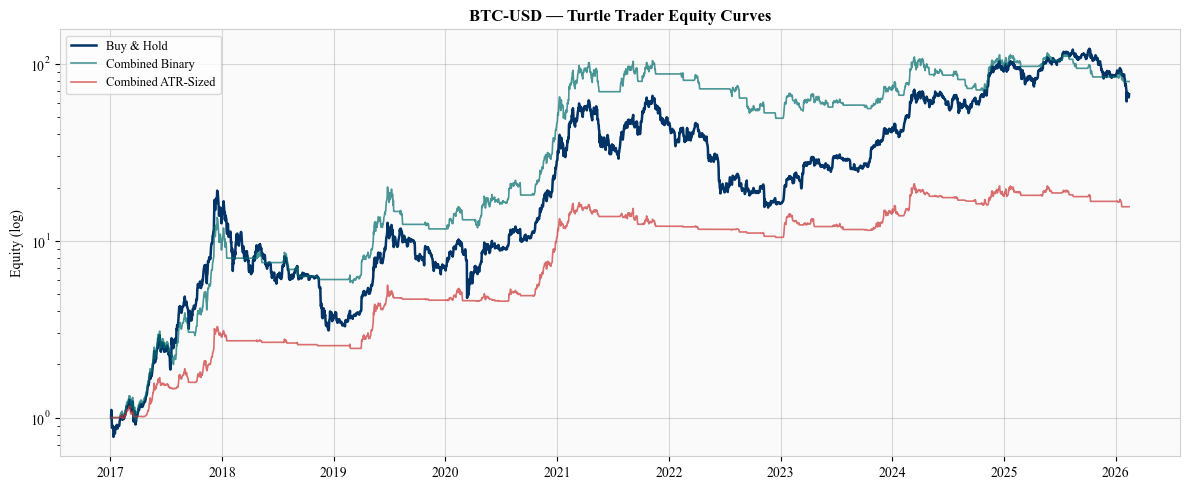

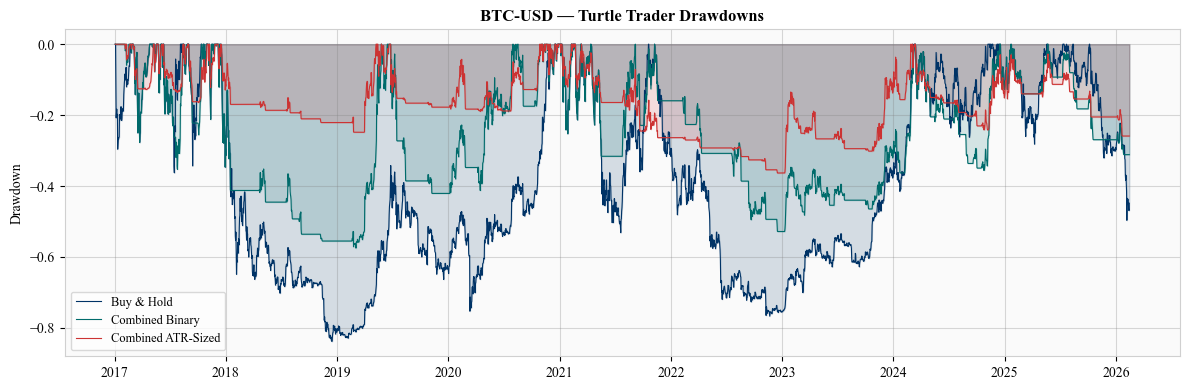

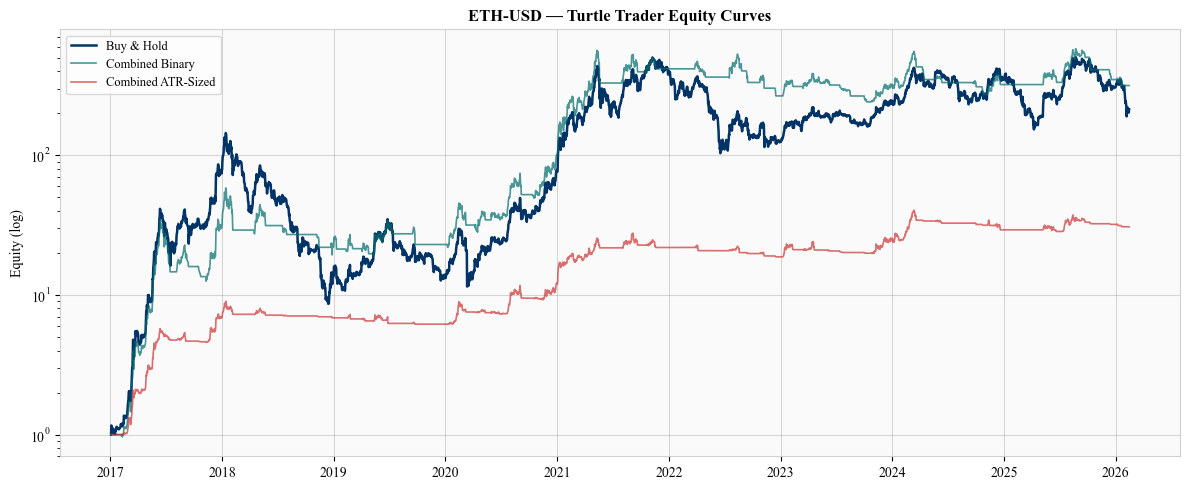

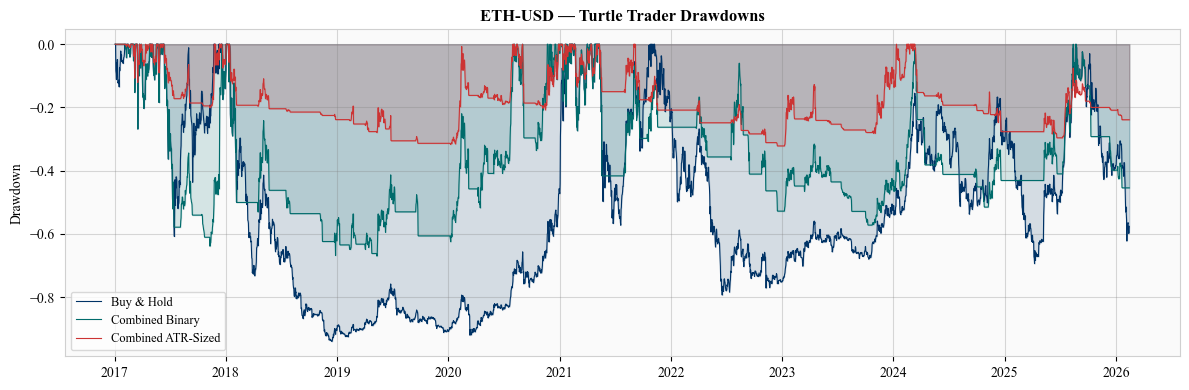

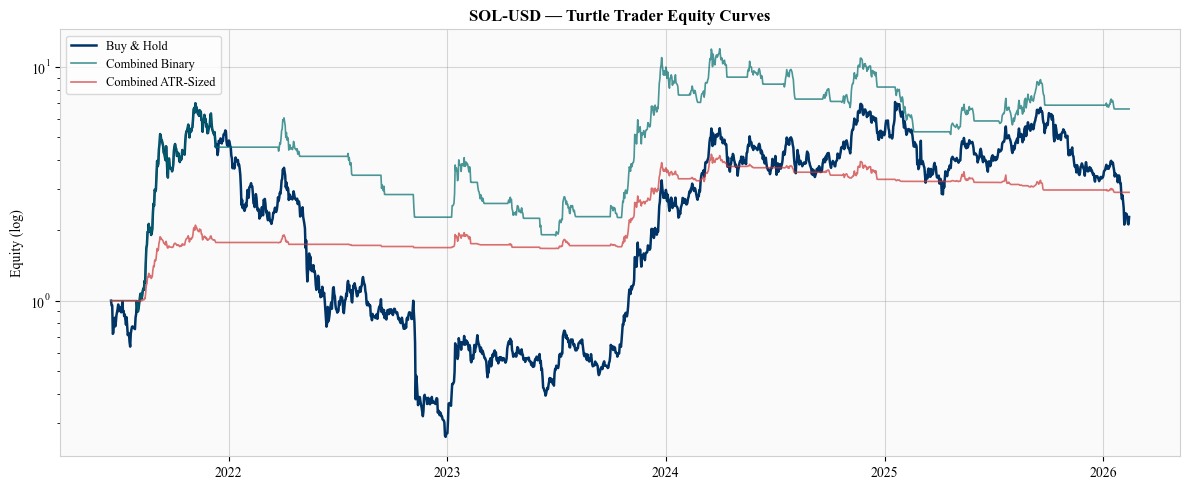

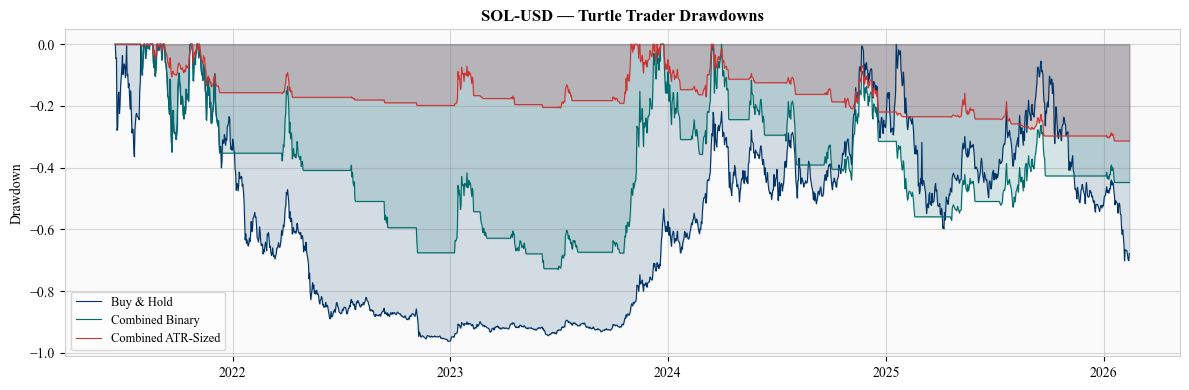

In [8]:
for sym, results in per_asset_results.items():
    # Show the key variants: B&H, Combined Binary, Combined ATR-Sized
    key_results = [r for r in results if r["label"] in ["Buy & Hold", "Combined Binary", "Combined ATR-Sized"]]
    plot_equity(key_results, title=f"{sym} — Turtle Trader Equity Curves")
    plt.show()

    plot_drawdowns(key_results, title=f"{sym} — Turtle Trader Drawdowns")
    plt.show()

## 7. Signal overlay — price + position for each asset

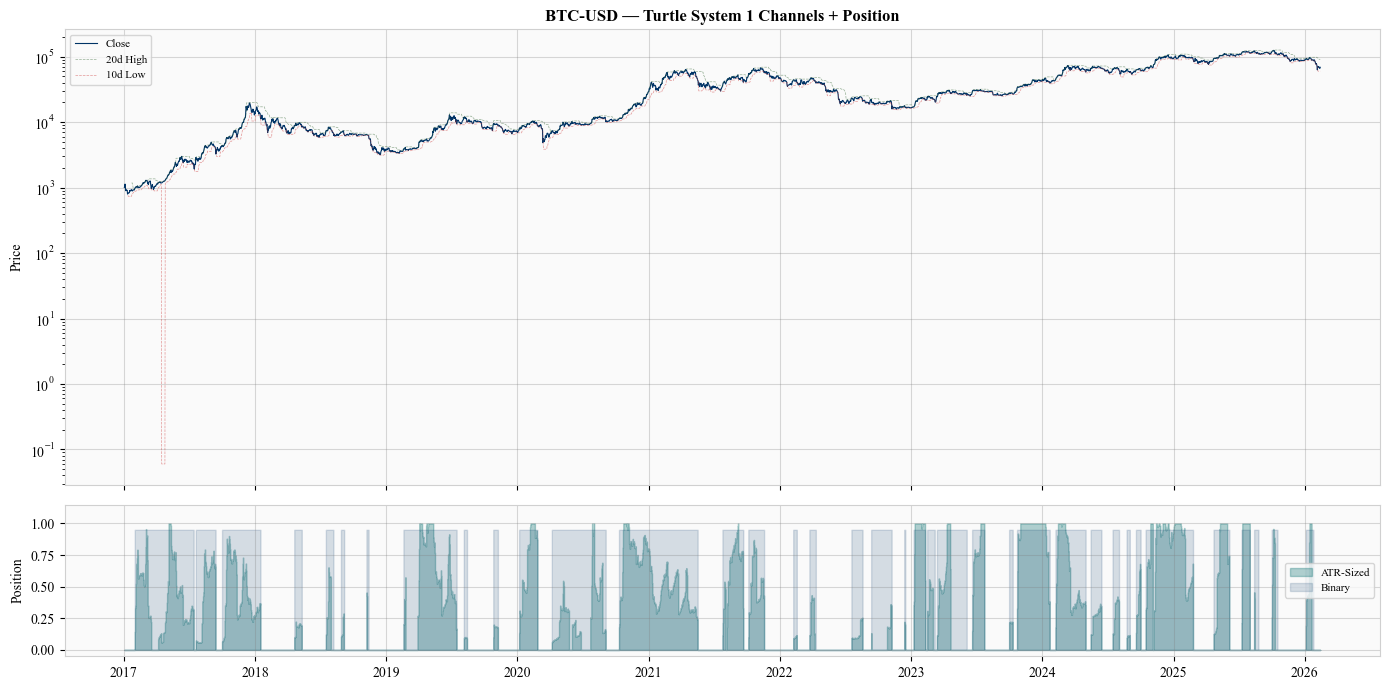

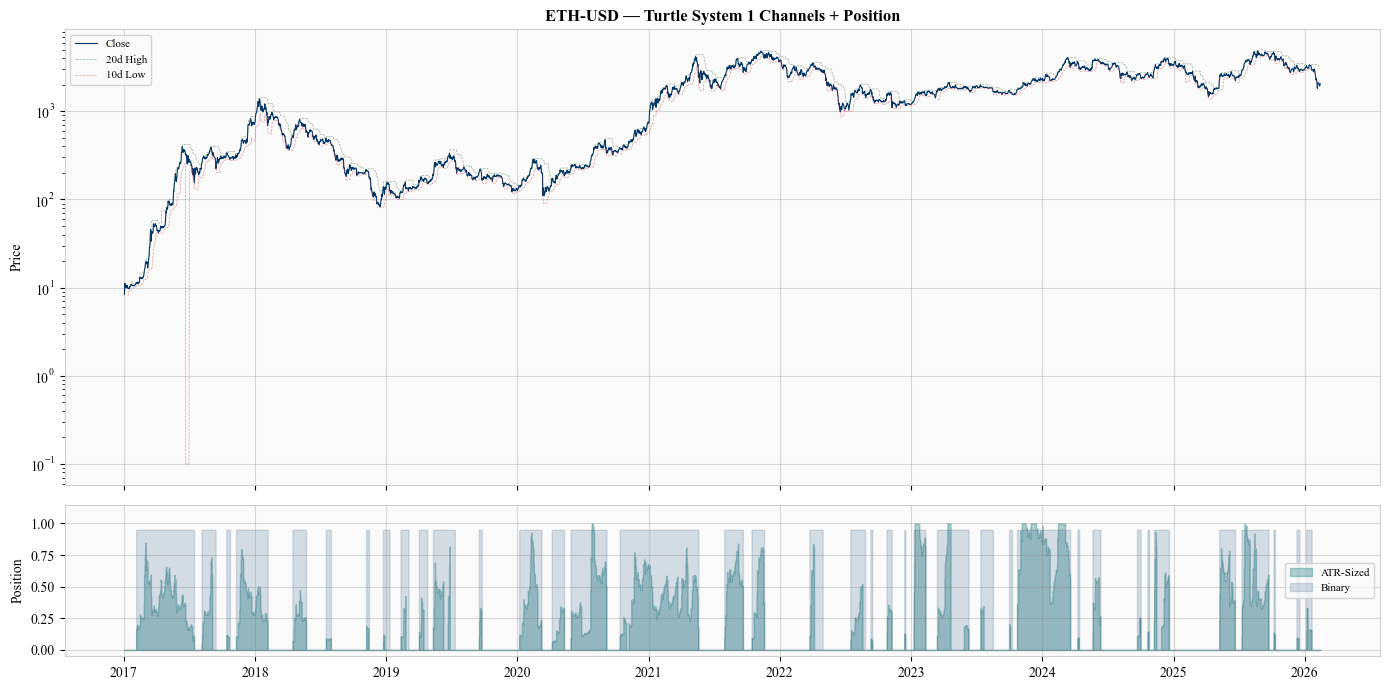

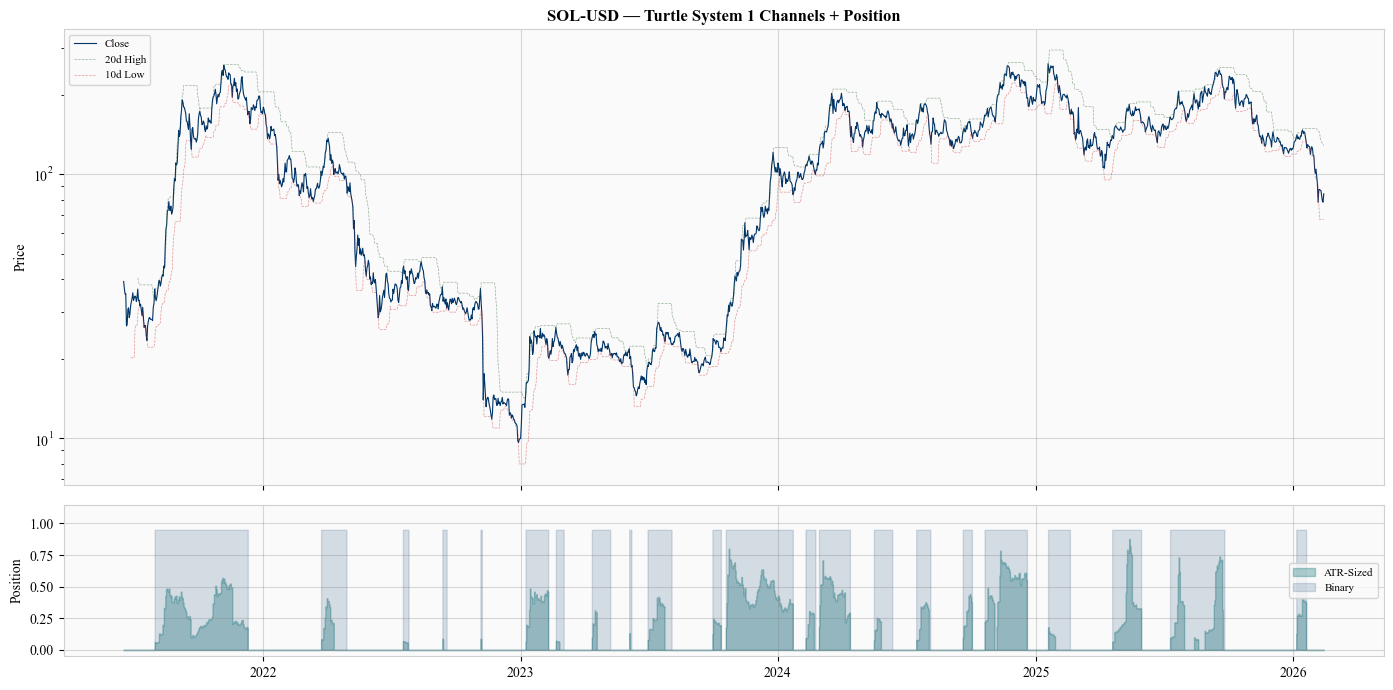

In [9]:
for sym, df in assets.items():
    close = df["close"]
    sig_bin = all_signals[sym]["Combined Binary"]
    sig_sized = all_signals[sym]["Combined ATR-Sized"]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                                    gridspec_kw={"height_ratios": [3, 1]})

    ax1.plot(close.index, close.values, color=NAVY, lw=0.8, label="Close")
    atr = compute_atr(df["high"], df["low"], close, ATR_PERIOD)
    entry_hi = df["high"].shift(1).rolling(SYS1_ENTRY).max()
    exit_lo  = df["low"].shift(1).rolling(SYS1_EXIT).min()
    ax1.plot(entry_hi.index, entry_hi.values, color=GREEN, lw=0.5, ls="--", alpha=0.5, label=f"{SYS1_ENTRY}d High")
    ax1.plot(exit_lo.index, exit_lo.values, color=RED, lw=0.5, ls="--", alpha=0.5, label=f"{SYS1_EXIT}d Low")
    ax1.set_ylabel("Price")
    ax1.set_title(f"{sym} — Turtle System 1 Channels + Position", fontweight="bold")
    ax1.legend(fontsize=8, loc="upper left")
    ax1.set_yscale("log")

    ax2.fill_between(sig_sized.index, sig_sized.values, alpha=0.3, color=TEAL, step="post", label="ATR-Sized")
    ax2.fill_between(sig_bin.index, sig_bin.values * 0.95, alpha=0.15, color=NAVY, step="post", label="Binary")
    ax2.set_ylabel("Position")
    ax2.set_ylim(-0.05, 1.15)
    ax2.legend(fontsize=8)

    fig.tight_layout()
    plt.show()

## 8. Multi-asset portfolio

Equal-risk allocation across assets using inverse-vol weighting, then overlay the Turtle signals.

In [11]:
# Build wide returns and weights
close_wide = pd.DataFrame({sym: df["close"] for sym, df in assets.items()})
returns_wide = close_wide.pct_change(fill_method=None)

# Combined ATR-Sized across assets
weights_sized = pd.DataFrame({
    sym: all_signals[sym]["Combined ATR-Sized"]
    for sym in assets
}).reindex(returns_wide.index).fillna(0.0)

# Normalize so total weight <= 1.0 (equal allocation budget per asset)
n_assets = len(assets)
weights_sized_normed = weights_sized / n_assets

# Combined Binary across assets (equal weight when in)
weights_binary = pd.DataFrame({
    sym: all_signals[sym]["Combined Binary"]
    for sym in assets
}).reindex(returns_wide.index).fillna(0.0)
weights_binary_normed = weights_binary / n_assets

# Equal-weight buy & hold
bh_wide = pd.DataFrame(1.0 / n_assets, index=returns_wide.index, columns=returns_wide.columns)

# Run portfolio backtests
port_results = [
    quick_backtest(weights_sized_normed, returns_wide, COST_BPS, "Turtle ATR-Sized Portfolio"),
    quick_backtest(weights_binary_normed, returns_wide, COST_BPS, "Turtle Binary Portfolio"),
    quick_backtest(bh_wide, returns_wide, COST_BPS, "EW Buy & Hold"),
]

print("Portfolio-level results:")
display(metrics_table(port_results))

Portfolio-level results:


,total_return,cagr,vol,sharpe,sortino,calmar,max_dd,hit_rate,skewness,kurtosis,n_days,avg_turnover,avg_gross
strategy,,,,,,,,,,,,,
Turtle ATR-Sized Portfolio,11.923182,32.4%,19.6%,1.53,1.60,1.42,-22.8%,31.1%,0.46,10.077358,3330,0.02,17.9%
Turtle Binary Portfolio,105.578346,66.8%,40.9%,1.46,1.72,1.23,-54.5%,34.1%,0.32,5.655980,3330,0.02,42.4%
EW Buy & Hold,85.069447,63.0%,64.8%,1.08,1.50,0.74,-85.5%,52.6%,-0.21,4.446151,3330,0.00,100.0%


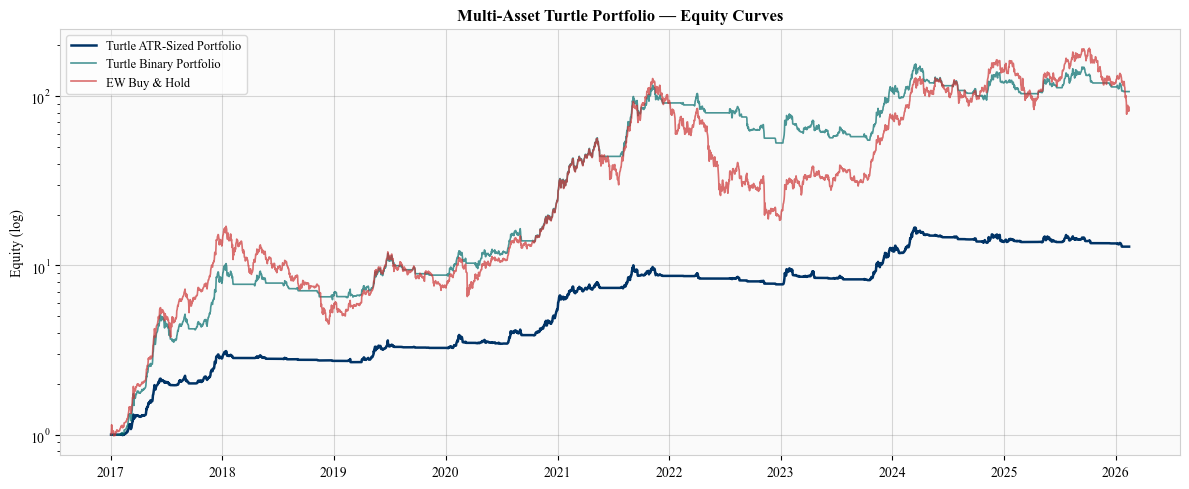

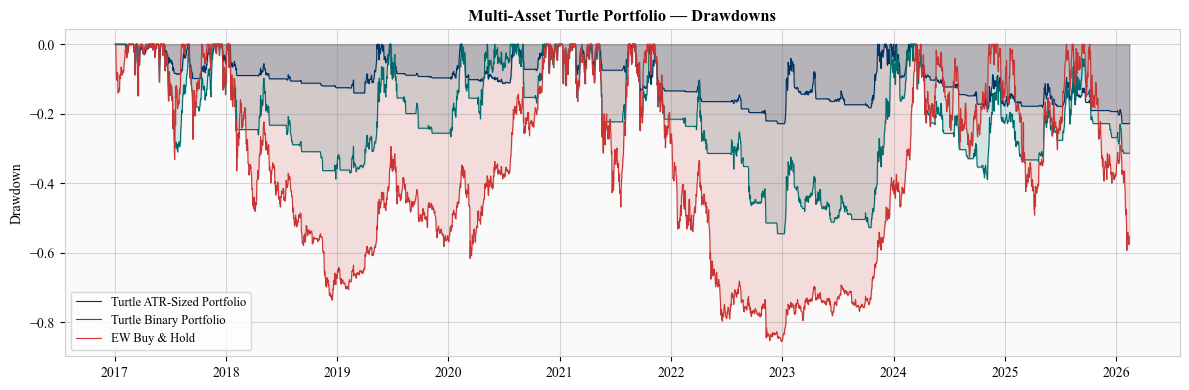

In [12]:
plot_equity(port_results, title="Multi-Asset Turtle Portfolio — Equity Curves")
plt.show()

plot_drawdowns(port_results, title="Multi-Asset Turtle Portfolio — Drawdowns")
plt.show()

## 9. Parameter sensitivity

Sweep key Turtle parameters on a single asset to understand sensitivity.

In [13]:
SWEEP_SYMBOL = "ETH-USD"
sweep_df = assets[SWEEP_SYMBOL]
sweep_close = sweep_df["close"]
sweep_high  = sweep_df["high"]
sweep_low   = sweep_df["low"]
sweep_ret   = sweep_close.pct_change(fill_method=None).dropna().to_frame(name=SWEEP_SYMBOL)

# Sweep entry/exit period combinations
entry_periods = [10, 20, 30, 40, 55, 80]
exit_periods  = [5, 10, 15, 20, 30]

sweep_rows = []
for ep in entry_periods:
    for xp in exit_periods:
        if xp >= ep:
            continue
        sig = turtle_signals(sweep_close, sweep_high, sweep_low, ep, xp)
        w = sig.to_frame(name=SWEEP_SYMBOL)
        r = quick_backtest(w, sweep_ret, COST_BPS, f"E{ep}/X{xp}")
        if r["metrics"]:
            sweep_rows.append({
                "entry": ep, "exit": xp,
                "sharpe": r["metrics"]["sharpe"],
                "cagr": r["metrics"]["cagr"],
                "max_dd": r["metrics"]["max_dd"],
                "tim": float(sig.mean()),
                "calmar": r["metrics"]["calmar"],
            })

sweep_df_result = pd.DataFrame(sweep_rows)
print(f"Tested {len(sweep_rows)} entry/exit combinations on {SWEEP_SYMBOL}")
display(sweep_df_result.sort_values("sharpe", ascending=False).round(3).head(15))

Tested 23 entry/exit combinations on ETH-USD


,entry,exit,sharpe,cagr,max_dd,tim,calmar
0,10,5,1.415,1.049,-0.606,0.469,1.732
7,30,20,1.342,0.994,-0.669,0.494,1.487
5,30,10,1.332,0.923,-0.675,0.388,1.368
1,20,5,1.288,0.817,-0.471,0.364,1.736
2,20,10,1.283,0.891,-0.708,0.430,1.258
14,55,10,1.276,0.796,-0.697,0.315,1.141
4,30,5,1.274,0.778,-0.514,0.326,1.513
6,30,15,1.270,0.879,-0.610,0.454,1.441
11,40,20,1.266,0.861,-0.703,0.446,1.225
3,20,15,1.253,0.884,-0.679,0.511,1.302


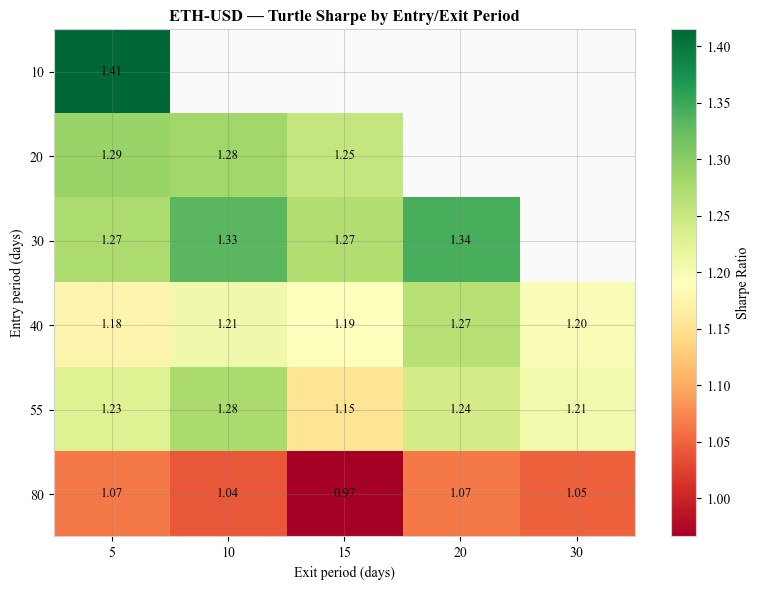

In [14]:
# Heatmap: Sharpe by entry/exit period
pivot = sweep_df_result.pivot(index="entry", columns="exit", values="sharpe")

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot.values, cmap="RdYlGn", aspect="auto",
               vmin=pivot.values[~np.isnan(pivot.values)].min(),
               vmax=pivot.values[~np.isnan(pivot.values)].max())
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("Exit period (days)")
ax.set_ylabel("Entry period (days)")
ax.set_title(f"{SWEEP_SYMBOL} — Turtle Sharpe by Entry/Exit Period", fontweight="bold")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9,
                    color="white" if val < 0.7 else "black")

fig.colorbar(im, ax=ax, label="Sharpe Ratio")
fig.tight_layout()
plt.show()

## 10. Year-by-year performance

In [18]:
# Year-by-year breakdown for the Combined ATR-Sized on each asset
for sym in assets:
    results_key = [r for r in per_asset_results[sym] if r["label"] in ["Buy & Hold", "Combined ATR-Sized"]]

    print(f"\n{'='*50}")
    print(f"  {sym} — Year-by-Year")
    print(f"{'='*50}")

    for r in results_key:
        eq = r["equity"]
        if eq.empty:
            continue
        eq.index = pd.to_datetime(eq.index)
        annual_ret = eq.resample("YE").last().pct_change().dropna()
        annual_ret.index = annual_ret.index.year
        print(f"\n  {r['label']}:")
        for yr, ret in annual_ret.items():
            print(f"    {yr}: {ret:+.1%}")


  BTC-USD — Year-by-Year

  Buy & Hold:
    2018: -73.4%
    2019: +94.1%
    2020: +304.6%
    2021: +59.4%
    2022: -64.2%
    2023: +155.8%
    2024: +120.8%
    2025: -6.3%
    2026: -21.4%

  Combined ATR-Sized:
    2018: -12.2%
    2019: +80.8%
    2020: +128.1%
    2021: +14.9%
    2022: -13.5%
    2023: +36.1%
    2024: +26.2%
    2025: -7.0%
    2026: -6.8%

  ETH-USD — Year-by-Year

  Buy & Hold:
    2018: -82.4%
    2019: -1.5%
    2020: +473.9%
    2021: +398.3%
    2022: -67.5%
    2023: +90.8%
    2024: +46.0%
    2025: -10.9%
    2026: -31.0%

  Combined ATR-Sized:
    2018: -0.9%
    2019: -9.8%
    2020: +94.6%
    2021: +81.7%
    2022: -14.3%
    2023: +31.5%
    2024: +18.8%
    2025: +9.4%
    2026: -3.8%

  SOL-USD — Year-by-Year

  Buy & Hold:
    2022: -94.1%
    2023: +920.0%
    2024: +85.7%
    2025: -34.1%
    2026: -32.3%

  Combined ATR-Sized:
    2022: -4.9%
    2023: +112.4%
    2024: -7.7%
    2025: -10.0%
    2026: -2.3%


## 11. Summary & observations

Key questions to evaluate:

1. **Does the Turtle system work on crypto?** Compare Sharpe to B&H across assets.
2. **Binary vs ATR-sized:** Does full Turtle sizing (with pyramiding) add value vs. simple binary?
3. **System 1 vs System 2:** Does the shorter-term breakout add enough vs. the longer-term?
4. **Drawdown compression:** How much does the channel exit reduce max DD vs. B&H?
5. **Parameter sensitivity:** Is the optimal entry/exit period stable or fragile?
6. **Year-by-year:** Does it protect in bear years (2018, 2022) while participating in bulls?

In [19]:
# Final summary table: best variant per asset
summary_rows = []
for sym, results in per_asset_results.items():
    for r in results:
        m = r.get("metrics", {})
        if not m:
            continue
        summary_rows.append({
            "asset": sym,
            "strategy": r["label"],
            "sharpe": m.get("sharpe"),
            "cagr": m.get("cagr"),
            "max_dd": m.get("max_dd"),
            "calmar": m.get("calmar"),
            "skewness": m.get("skewness"),
        })

summary = pd.DataFrame(summary_rows)
summary["cagr"] = summary["cagr"].map("{:.1%}".format)
summary["max_dd"] = summary["max_dd"].map("{:.1%}".format)
summary[["sharpe", "calmar", "skewness"]] = summary[["sharpe", "calmar", "skewness"]].round(2)

display(summary.set_index(["asset", "strategy"]))

sharpe   cagr  max_dd  calmar  skewness
asset   strategy                                                   
BTC-USD Buy & Hold            1.01  58.6%  -83.8%    0.70     -0.01
        Sys1 Binary           1.26  62.1%  -53.1%    1.17      0.88
        Sys2 Binary           1.03  43.7%  -53.2%    0.82      0.76
        Combined Binary       1.21  61.6%  -57.5%    1.07      0.71
        Sys1 ATR-Sized        1.23  21.4%  -20.2%    1.06      1.59
        Sys2 ATR-Sized        0.91  13.4%  -22.1%    0.60      1.15
        Combined ATR-Sized    1.19  35.1%  -36.3%    0.97      1.25
ETH-USD Buy & Hold            1.09  80.0%  -94.0%    0.85      0.36
        Sys1 Binary           1.28  89.1%  -70.8%    1.26      1.50
        Sys2 Binary           1.24  79.2%  -69.7%    1.14      1.55
        Combined Binary       1.25  87.9%  -67.0%    1.31      1.17
        Sys1 ATR-Sized        1.25  21.7%  -19.4%    1.12      1.56
        Sys2 ATR-Sized        1.35  23.0%  -17.6%    1.31      1.95
        Combined ATR-Sized    1.34  45.6%  -32.2%    1.42      1.96
SOL-USD Buy & Hold            0.68  19.4%  -96.3%    0.20      0.17
        Sys1 Binary           1.04  58.3%  -68.7%    0.85      1.97
        Sys2 Binary           0.94  47.9%  -68.0%    0.70      2.17
        Combined Binary       0.93  50.0%  -73.0%    0.69      1.71
        Sys1 ATR-Sized        0.97  13.2%  -16.0%    0.83      2.09
        Sys2 ATR-Sized        1.03  12.6%  -17.1%    0.74      1.93
        Combined ATR-Sized    1.05  25.8%  -31.3%    0.82      2.10